# Bonus Challenge: Monte Carlo NAV Projection

## Objective
Project future NAV growth for a mutual fund using Monte Carlo Simulation.

### Method
- Use historical daily returns.
- Calculate average daily return and volatility.
- Simulate 1000 possible NAV paths.
- Forecast over a 5-year horizon (252 trading days × 5).
- Visualize uncertainty in future fund performance.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load NAV data
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
# Select first fund
fund_code = nav['amfi_code'].unique()[0]

fund = nav[
    nav['amfi_code'] == fund_code
].copy()

print("Fund Code:", fund_code)

fund.tail()

Fund Code: 100016


,amfi_code,date,nav,daily_return
1145,100016,2026-05-25,599.9335,-0.004227
1146,100016,2026-05-26,596.4426,-0.005819
1147,100016,2026-05-27,590.8555,-0.009367
1148,100016,2026-05-28,590.9452,0.000152
1149,100016,2026-05-29,583.6113,-0.012410


In [9]:
returns = fund['daily_return'].dropna()

mu = returns.mean()
sigma = returns.std()

last_nav = fund['nav'].iloc[-1]

print("Average Daily Return:", round(mu,6))
print("Daily Volatility:", round(sigma,6))
print("Latest NAV:", round(last_nav,2))

Average Daily Return: 0.000142
Daily Volatility: 0.009164
Latest NAV: 583.61


In [10]:
days = 252 * 5
simulations = 1000

results = np.zeros(
    (days, simulations)
)

for sim in range(simulations):

    prices = [last_nav]

    for _ in range(days - 1):

        shock = np.random.normal(
            mu,
            sigma
        )

        prices.append(
            prices[-1] * (1 + shock)
        )

    results[:, sim] = prices

print("Simulation Complete")

Simulation Complete


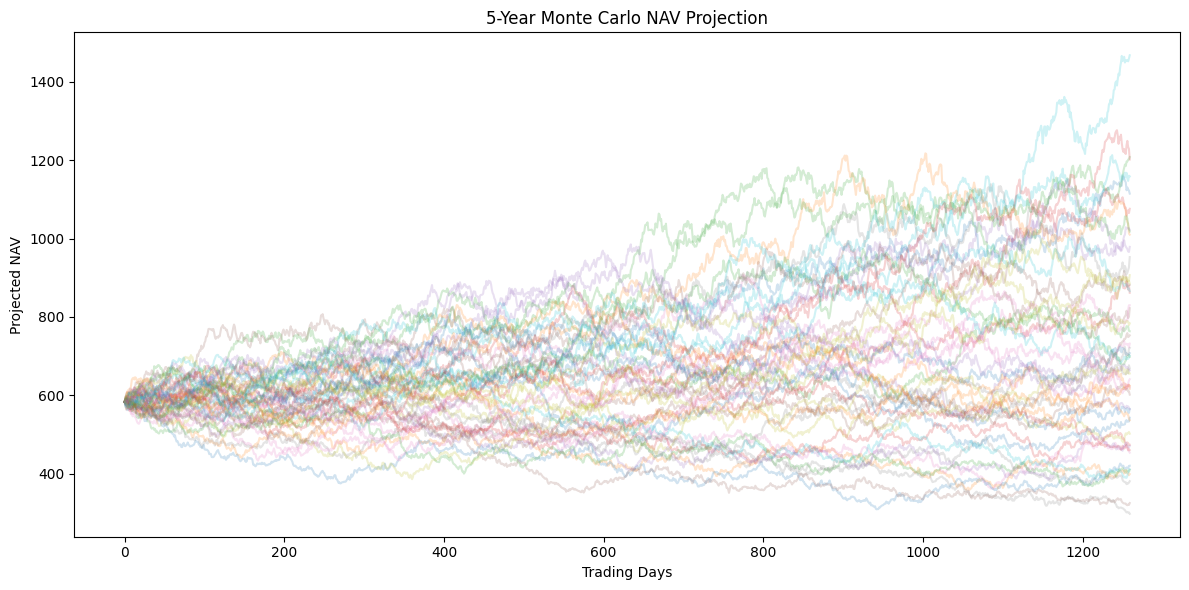

In [11]:
plt.figure(figsize=(12,6))

for i in range(50):
    plt.plot(
        results[:, i],
        alpha=0.2
    )

plt.title(
    "5-Year Monte Carlo NAV Projection"
)

plt.xlabel(
    "Trading Days"
)

plt.ylabel(
    "Projected NAV"
)

plt.tight_layout()

plt.savefig(
    "../reports/monte_carlo_projection.png"
)

plt.show()

In [12]:
final_values = results[-1]

print("Projected NAV Statistics")

print(
    "Mean:",
    round(final_values.mean(),2)
)

print(
    "Median:",
    round(np.median(final_values),2)
)

print(
    "5th Percentile:",
    round(np.percentile(final_values,5),2)
)

print(
    "95th Percentile:",
    round(np.percentile(final_values,95),2)
)

Projected NAV Statistics
Mean: 700.47
Median: 652.52
5th Percentile: 388.91
95th Percentile: 1139.01


# Monte Carlo Simulation Insights

1. A total of 1000 future NAV paths were simulated using historical daily return distributions.

2. The simulation provides a range of possible outcomes rather than a single prediction.

3. The 5th percentile represents a pessimistic scenario while the 95th percentile represents an optimistic scenario.

4. Higher volatility increases the spread between possible future NAV outcomes.

5. Monte Carlo analysis helps investors understand uncertainty and long-term risk in mutual fund investments.